# Lecture 8c — Testing a factor model

**AI-powered Investment and Risk Management (25882) · Vitali Alexeev · UTS Business School**

Lecture 8b *built* portfolios. This notebook *tests* models.

The distinction matters more than it sounds. A model that forecasts returns well may
still be a bad asset pricing model, and a model that prices assets well may forecast
nothing. Here we ask the pricing question directly: **given a set of test assets, does
this model explain their average returns, or does it leave money on the table?**

### What we do

1. Parse the Ken French files as they actually arrive — copyright headers, stacked
   panels, `-99.99` missing codes and all.
2. Estimate the CAPM baseline and look at where it fails.
3. Compute time-series alphas: the pricing errors that are the object of interest.
4. Run the **GRS test**, which asks whether all the alphas are jointly zero.
5. Run **Fama–MacBeth** cross-sectional regressions with the **Shanken** correction.
6. Turn the machinery on the 158 anomalies from Lecture 8b and see whether the
   standard models can price them.

*Runtime: 2–4 minutes.*

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import plotly.graph_objects as go

import airm8
from airm8 import *

pd.set_option("display.precision", 4)

# FF5 begins in July 1963. Every model comparison below uses this window so
# that differences reflect the models, not the samples.
START = "1963-07"

---
## 1. The data, as it actually arrives

Files from the Ken French Data Library are not tidy. One download contains a
copyright preamble, then several panels stacked one after another — value-weighted
monthly returns, then equal-weighted, then annual versions, then firm counts and
average sizes. Missing values are coded `-99.99` or `-999`, and returns are in
percent.

`airm8.load_french` handles all of it. Look at what is inside one file before we go
further, because the habit of checking is worth more than the parser.

In [2]:
for key in ["ff3", "ff5", "size_bm", "industry"]:
    panels = french_panels(key)
    print(f"{key:9s} {len(panels)} panel(s)")
    for p in panels[:4]:
        print(f"            · {p[:66]}")

ff3       2 panel(s)
            · The annual TBill return is compounded from the monthly T-bill rate
            · Annual Factors: January-December
ff5       2 panel(s)
            · The annual TBill return is compounded from the monthly T-bill rate
            · Annual Factors: January-December
size_bm   10 panel(s)
            · Average Value Weighted Returns -- Monthly
            · Average Equal Weighted Returns -- Monthly
            · Average Value Weighted Returns -- Annual
            · Average Equal Weighted Returns -- Annual
industry  8 panel(s)
            · Average Value Weighted Returns -- Monthly
            · Average Equal Weighted Returns -- Monthly
            · Average Value Weighted Returns -- Annual
            · Average Equal Weighted Returns -- Annual


In [3]:
factors, rf = load_factors("ff5", start=START)
print(f"FF5 factors: {factors.shape[0]} months, "
      f"{factors.index.min():%Y-%m} to {factors.index.max():%Y-%m}")
print(f"Columns: {list(factors.columns)}\n")
print((factors.mean() * 12).round(4).to_frame("mean return p.a.").to_string())
print(f"\nRisk-free rate, mean p.a.: {rf.mean() * 12:.2%}")

FF5 factors: 756 months, 1963-07 to 2026-06
Columns: ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']

        mean return p.a.
Mkt-RF            0.0721
SMB               0.0224
HML               0.0358
RMW               0.0287
CMA               0.0295

Risk-free rate, mean p.a.: 4.36%


### One alignment trap worth knowing about

Chen and Zimmermann stamp each observation with the last **trading** day of the
month. Ken French uses the last **calendar** day. Join them on raw timestamps and
every month whose end fell on a weekend silently disappears — in our window that is
178 of 600 months, about 30% of the sample, lost without any error message.

`airm8` normalises both to month-end. This class of bug produces no warning, changes
your results, and is invisible unless you check the sample size. **Always print the
number of observations after a merge.**

---
## 2. The single-factor baseline

Start where asset pricing starts. The CAPM says one number describes an asset's risk:

$$\mathbb{E}[R^e_i] = \beta_i \, \mathbb{E}[R^e_m].$$

Estimate $\beta_i$ for the 25 portfolios sorted on size and book-to-market, then check
whether average returns line up with betas the way the theory requires.

In [4]:
capm_factors, _ = load_factors("capm", start=START)
size_bm = load_test_assets("size_bm", rf=rf, start=START)

alphas, betas, resid, r2 = time_series_alphas(size_bm, capm_factors)

summary = pd.DataFrame({
    "mean_return_pa": size_bm.mean() * 12,
    "beta": betas["Mkt-RF"],
    "alpha_pct_pm": alphas * 100,
    "r2": r2,
})
print(summary.round(3).to_string())

            mean_return_pa   beta  alpha_pct_pm     r2
SMALL LoBM           0.039  1.416        -0.522  0.629
ME1 BM2              0.095  1.219         0.059  0.617
ME1 BM3              0.097  1.111         0.137  0.664
ME1 BM4              0.116  1.034         0.347  0.625
SMALL HiBM           0.133  1.064         0.473  0.575
ME2 BM1              0.067  1.378        -0.266  0.735
ME2 BM2              0.098  1.183         0.103  0.750
ME2 BM3              0.107  1.081         0.245  0.746
ME2 BM4              0.108  1.015         0.291  0.711
ME2 BM5              0.121  1.140         0.320  0.668
ME3 BM1              0.068  1.306        -0.220  0.794
ME3 BM2              0.095  1.116         0.124  0.816
ME3 BM3              0.090  1.014         0.144  0.792
ME3 BM4              0.104  0.996         0.272  0.745
ME3 BM5              0.119  1.083         0.344  0.670
ME4 BM1              0.078  1.192        -0.069  0.845
ME4 BM2              0.079  1.075         0.016  0.870
ME4 BM3   

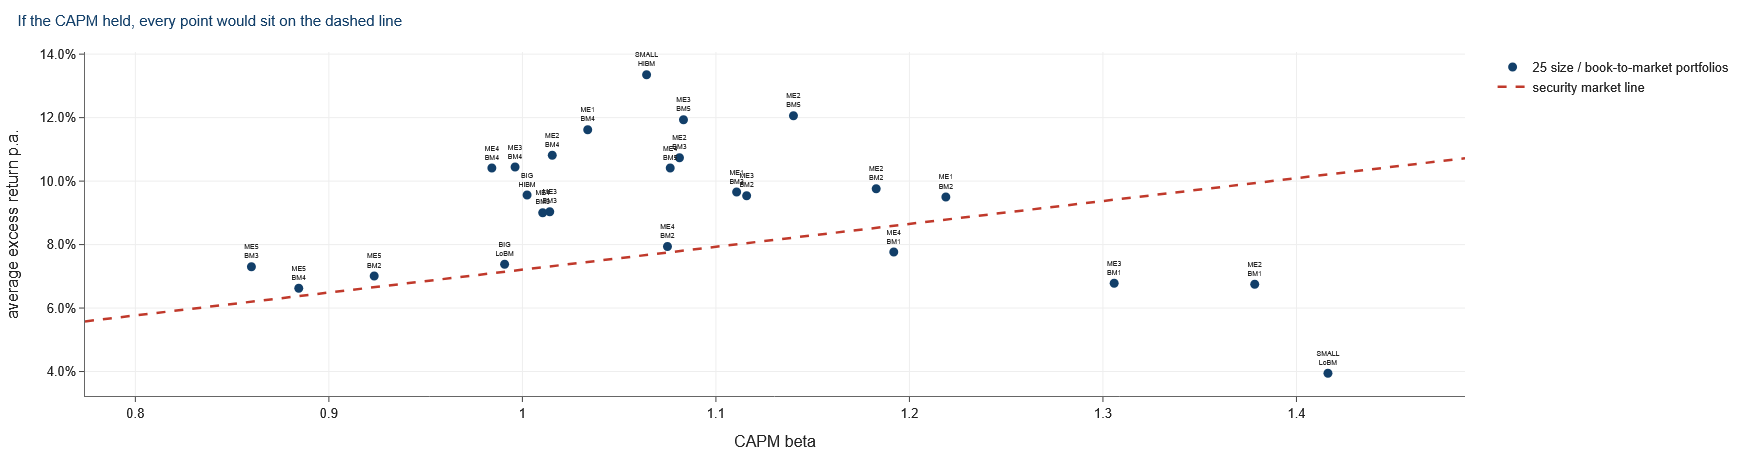

In [5]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=summary.beta, y=summary.mean_return_pa, mode="markers+text",
    text=[c.replace(" ", "<br>") for c in summary.index],
    textposition="top center", textfont=dict(size=7),
    marker=dict(color=NAVY, size=9), name="25 size / book-to-market portfolios"))

# The security market line the CAPM predicts.
b = np.linspace(summary.beta.min() * 0.9, summary.beta.max() * 1.05, 20)
fig.add_trace(go.Scatter(x=b, y=b * capm_factors["Mkt-RF"].mean() * 12,
                         mode="lines", name="security market line",
                         line=dict(color=RED, width=2.5, dash="dash")))
fig.update_xaxes(title="CAPM beta")
fig.update_yaxes(title="average excess return p.a.", tickformat=".1%")
airm_layout(fig, "If the CAPM held, every point would sit on the dashed line")

The points do not sit on the line, and they miss it in a *pattern* rather than at
random. The portfolios with the highest average returns are not the ones with the
highest betas. Some of the highest-beta portfolios earn among the lowest returns.

That pattern is the entire origin story of the Fama–French factors. Size and value
were added precisely because CAPM residuals lined up with size and value.

---
## 3. Pricing errors

Run the time-series regression for each test asset against whatever factors the model
proposes:

$$R^e_{i,t} = \alpha_i + \beta_i' f_t + \varepsilon_{i,t}.$$

If the model is right, every $\alpha_i$ is zero. The alphas are the **pricing
errors** — what the model fails to explain — and they are what an investor could
harvest by trading against the model.

In [6]:
rows = []
for name in ["capm", "ff3", "ff5"]:
    f, _ = load_factors(name, start=START)
    a, _, _, r = time_series_alphas(size_bm, f)
    rows.append(pd.Series(a * 100, name=name.upper()))
    rows.append(pd.Series(r, name=f"{name.upper()} R²"))

compare = pd.concat(rows, axis=1)
print("Alphas (% per month) and time-series fit, 25 size / book-to-market:\n")
print(compare.round(3).to_string())

Alphas (% per month) and time-series fit, 25 size / book-to-market:

             CAPM  CAPM R²    FF3  FF3 R²    FF5  FF5 R²
SMALL LoBM -0.522    0.629 -0.465   0.903 -0.275   0.921
ME1 BM2     0.059    0.617  0.013   0.924  0.153   0.936
ME1 BM3     0.137    0.664 -0.008   0.943  0.044   0.946
ME1 BM4     0.347    0.625  0.130   0.950  0.161   0.951
SMALL HiBM  0.473    0.575  0.173   0.908  0.150   0.906
ME2 BM1    -0.266    0.735 -0.168   0.940 -0.061   0.952
ME2 BM2     0.103    0.750  0.032   0.944  0.050   0.951
ME2 BM3     0.245    0.746  0.078   0.927  0.046   0.937
ME2 BM4     0.291    0.711  0.050   0.945  0.027   0.948
ME2 BM5     0.320    0.668 -0.013   0.954 -0.014   0.953
ME3 BM1    -0.220    0.794 -0.104   0.939 -0.011   0.946
ME3 BM2     0.124    0.816  0.048   0.918  0.008   0.928
ME3 BM3     0.144    0.792 -0.030   0.904 -0.091   0.916
ME3 BM4     0.272    0.745  0.020   0.917 -0.023   0.924
ME3 BM5     0.344    0.670  0.001   0.906 -0.040   0.911
ME4 BM1    -0.069  

Two different things improve as factors are added, and it is worth separating them.

The **$R^2$ columns** rise sharply: FF3 and FF5 describe the *variation* in these
portfolios far better than the CAPM. That is about risk exposure.

The **alphas** shrink but do not vanish. That is about pricing, and it is the harder
test. A model can track a portfolio's ups and downs almost perfectly and still get
its average return wrong.

---
## 4. The GRS test

Individual $t$-statistics on 25 alphas invite exactly the multiple-testing problem
from Lecture 8b. The GRS test asks the joint question instead: **are all $N$ pricing
errors zero at once?**

<details>
<summary><b>The maths: the GRS statistic and what each piece does</b> (click to expand)</summary>

$$\text{GRS} = \frac{T-N-K}{N}
\left(1 + \bar f' \hat\Omega^{-1} \bar f\right)^{-1}
\hat\alpha' \hat\Sigma^{-1} \hat\alpha
\;\sim\; F_{N,\,T-N-K}$$

- $\hat\alpha' \hat\Sigma^{-1} \hat\alpha$ is the squared Sharpe ratio of the
  portfolio built *purely from the pricing errors* — the best deviation from the
  model an investor could construct. Weighting by $\hat\Sigma^{-1}$ means alphas
  in low-residual-variance assets count for more, correctly.
- $(1 + \bar f' \hat\Omega^{-1} \bar f)^{-1}$ discounts the statistic by how good
  the model's own factors already are. A model whose factors span a high Sharpe
  ratio is held to a gentler standard.
- $(T-N-K)/N$ is the degrees-of-freedom adjustment, and it requires $T > N + K$.
  With 158 anomalies and 60 years of monthly data this binds — one reason the
  literature moved towards comparing SDF Sharpe ratios instead.

</details>

In [7]:
result = grs_test(size_bm, factors)
labels = {"grs": "GRS statistic", "p_value": "p-value", "df1": "N (assets)",
          "df2": "T - N - K", "T": "months", "N": "test assets",
          "K": "factors", "mean_abs_alpha": "mean |alpha| (%/month)",
          "sharpe_of_alphas": "Sharpe of the alphas",
          "sharpe_of_factors": "Sharpe of the factors"}
for k, label in labels.items():
    v = result[k] * 100 if k == "mean_abs_alpha" else result[k]
    print(f"   {label:26s} {v:10.4f}" if isinstance(v, float)
          else f"   {label:26s} {v:>10}")

   GRS statistic                  3.2055
   p-value                        0.0000
   N (assets)                         25
   T - N - K                         726
   months                            756
   test assets                        25
   factors                             5
   mean |alpha| (%/month)         0.0873
   Sharpe of the alphas           0.3446
   Sharpe of the factors          0.2756


Read `sharpe_of_alphas` against `sharpe_of_factors`. The first is the Sharpe ratio
available from trading the model's mistakes; the second is what the model's own
factors deliver. When the mistakes are worth more than the factors, the model is not
merely rejected on a technicality.

In [8]:
# The full grid: four models against three sets of test assets, common sample.
grid = []
for model, momentum in [("capm", False), ("ff3", False),
                        ("ff3", True), ("ff5", False)]:
    f, r = load_factors(model, start=START, with_momentum=momentum)
    label = "CARHART" if momentum else model.upper()
    for assets in ["size_bm", "size_op", "industry"]:
        R = load_test_assets(assets, rf=r, start=START)
        g = grs_test(R, f)
        grid.append(dict(model=label, assets=assets, N=g["N"], T=g["T"],
                         GRS=g["grs"], p=g["p_value"],
                         mean_abs_alpha=g["mean_abs_alpha"] * 100,
                         sharpe_alphas=g["sharpe_of_alphas"]))

grid = pd.DataFrame(grid)
print("Mean absolute alpha, % per month:\n")
print(grid.pivot_table(index="model", columns="assets",
                       values="mean_abs_alpha").round(3).to_string())
print("\nGRS statistic:\n")
print(grid.pivot_table(index="model", columns="assets",
                       values="GRS").round(2).to_string())
print(f"\nLargest p-value anywhere in the grid: {grid.p.max():.4f}")

Mean absolute alpha, % per month:

assets   industry  size_bm  size_op
model                              
CAPM        0.151    0.198    0.154
CARHART     0.168    0.080    0.087
FF3         0.192    0.087    0.093
FF5         0.226    0.087    0.064

GRS statistic:

assets   industry  size_bm  size_op
model                              
CAPM         1.41     4.16     2.15
CARHART      1.74     3.11     2.09
FF3          1.94     3.60     2.40
FF5          2.42     3.21     2.05

Largest p-value anywhere in the grid: 0.0397


## 4a. Every model is rejected. Everywhere.

Not one cell in that grid survives at the 5% level. This is the normal state of
affairs in empirical asset pricing, and it is why "the model was rejected" is not a
useful summary of anything. The interesting information is in *how* and *where*.

**On size and book-to-market**, adding factors helps as advertised: mean absolute
alpha falls from about 0.20% per month under the CAPM to roughly 0.09% under FF3 and
FF5.

**On size and profitability**, FF5 does best — 0.064% per month. It should: RMW and
CMA were constructed with exactly these patterns in mind. A model tested on the
portfolios that motivated it is being graded on its own homework.

**On industries, the elaborate models are worse than the CAPM.** Mean absolute alpha
*rises* from 0.151% to 0.226% as you go from the CAPM to FF5, and the GRS statistic
rises with it. Adding factors made the pricing errors bigger.

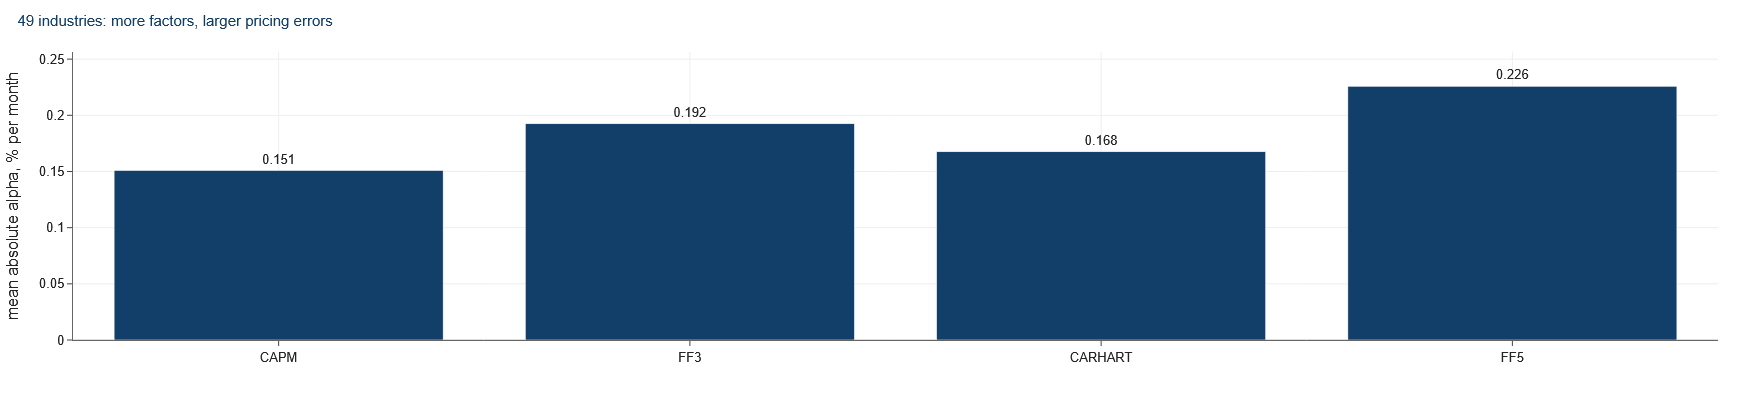

In [9]:
ind = grid[grid.assets == "industry"].set_index("model")
fig = go.Figure()
fig.add_trace(go.Bar(x=ind.index, y=ind.mean_abs_alpha, marker_color=NAVY,
                     text=[f"{v:.3f}" for v in ind.mean_abs_alpha],
                     textposition="outside", cliponaxis=False))
fig.update_yaxes(title="mean absolute alpha, % per month")
airm_layout(fig, "49 industries: more factors, larger pricing errors", height=400)

That result is not a quirk of our sample. The Fama–French factors are built from
sorts on firm characteristics, and industries are not a characteristic sort. Nothing
in the construction of SMB, HML, RMW or CMA obliges them to span industry returns,
so the extra factors add estimation noise without adding explanatory power.

The lesson generalises well beyond this table:

> A model's verdict depends on what you ask it to price. Report the test assets with
> the same prominence as the result, and be suspicious when someone does not.

This is the same lesson the principal-component result taught in Lecture 8b, arriving
from the opposite direction.

---
## 5. Fama–MacBeth, and why the standard errors are wrong

The GRS test asks whether the model prices assets. Fama–MacBeth asks a different
question: **what is the market paying for exposure to each factor?**

Two passes. First, time-series betas for every asset. Then, one cross-sectional
regression per month of returns on those betas, giving a series of risk-price
estimates $\hat\lambda_t$. Inference comes from how much those estimates move.

<details>
<summary><b>The maths: why the second pass has an errors-in-variables problem</b> (click to expand)</summary>

The second-stage regressor is $\hat\beta_i$, not $\beta_i$. Writing
$\hat\beta_i = \beta_i + u_i$, classical errors-in-variables **attenuates** the
estimated risk price towards zero and **understates** its standard error, because
the usual formula treats the regressor as known.

Shanken (1992) shows the correction is multiplicative: inflate the Fama–MacBeth
variance by

$$1 + \hat\lambda' \hat\Omega_f^{-1} \hat\lambda,$$

where $\hat\Omega_f$ is the factor covariance matrix. The size of that multiplier
is itself informative — it tells you how much first-stage noise you are carrying
into the second stage.

</details>

In [10]:
fm = fama_macbeth(size_bm, factors)
print("Fama-MacBeth on 25 size / book-to-market portfolios, FF5:\n")
print(fm.round(4).to_string())
print(f"\nShanken multiplier      {fm.attrs['shanken_multiplier']:.4f}")
print(f"Cross-sectional R²      {fm.attrs['cross_sectional_r2']:.3f}")

Fama-MacBeth on 25 size / book-to-market portfolios, FF5:

           estimate   se_fm    t_fm  se_shanken  t_shanken
intercept    0.0105  0.0026  3.9662      0.0028     3.7683
Mkt-RF      -0.0048  0.0031 -1.5424      0.0033    -1.4654
SMB          0.0025  0.0011  2.2567      0.0012     2.1441
HML          0.0029  0.0011  2.6690      0.0012     2.5358
RMW          0.0043  0.0017  2.5441      0.0018     2.4172
CMA         -0.0013  0.0017 -0.7360      0.0018    -0.6993

Shanken multiplier      1.0525
Cross-sectional R²      0.756


### Three things to notice

**The Shanken correction barely matters here.** The multiplier is about 1.05, so the
$t$-statistics move in the second decimal place. With 756 monthly observations the
first-stage betas are precisely estimated. Report it anyway — in a short sample, or
with noisier test assets, it can be substantial, and a reader cannot tell which case
they are in unless you show them.

**The intercept is significantly positive.** For excess returns, theory says it
should be zero. It is not, and that is a model failure visible without any joint test.

**The market risk price has the wrong sign.** Compare the estimated $\lambda$ on
`Mkt-RF` with the market factor's own average excess return:

In [11]:
comparison = pd.DataFrame({
    "lambda_from_cross_section": fm.loc[factors.columns, "estimate"] * 12,
    "factor_mean_return": factors.mean() * 12,
})
comparison["difference"] = (comparison.lambda_from_cross_section
                            - comparison.factor_mean_return)
print(comparison.round(4).to_string())

        lambda_from_cross_section  factor_mean_return  difference
Mkt-RF                    -0.0577              0.0721     -0.1298
SMB                        0.0306              0.0224      0.0082
HML                        0.0354              0.0358     -0.0004
RMW                        0.0515              0.0287      0.0228
CMA                       -0.0153              0.0295     -0.0448


Theory is unambiguous here: for a traded factor, the risk price recovered from the
cross-section should equal the factor's own average excess return. You can buy the
factor directly, so the two must agree.

They do not. The market's estimated risk price comes out **negative** while the market
earned about 7% a year over this sample.

This is a well-known failure and not a coding error. The 25 size and book-to-market
portfolios have very similar market betas — they are all diversified equity
portfolios — so there is almost no cross-sectional variation in $\beta_{\text{mkt}}$
from which to identify its price. The regression is being asked to measure a slope
across a range of $x$ that barely varies, and it returns noise.

**Test assets that do not spread out on a dimension cannot price that dimension.**

In [12]:
for assets in ["size_bm", "size_op", "industry"]:
    R = load_test_assets(assets, rf=rf, start=START)
    f = fama_macbeth(R, factors)
    g = grs_test(R, factors)
    print(f"{assets:9s} cross-sectional R² {f.attrs['cross_sectional_r2']: .3f}"
          f"   Shanken multiplier {f.attrs['shanken_multiplier']:.3f}"
          f"   Sharpe of alphas {g['sharpe_of_alphas']:.3f}")

size_bm   cross-sectional R²  0.756   Shanken multiplier 1.053   Sharpe of alphas 0.345
size_op   cross-sectional R²  0.836   Shanken multiplier 1.008   Sharpe of alphas 0.275
industry  cross-sectional R²  0.140   Shanken multiplier 1.012   Sharpe of alphas 0.417


FF5 explains about 84% of the cross-section of profitability-sorted portfolios, 76%
of size and value — and **14% of industries**. The same model, the same sample, the
same estimation. Only the question changed.

---
## 6. Closing the loop: can these models price the zoo?

Lecture 8b assembled 158 published anomaly long–short portfolios. Those are test
assets too. If the standard models price them, the factor zoo is not a puzzle — it is
a long list of redundant repackagings of size, value, profitability and investment.

Let us find out.

In [13]:
zoo = load_open_source_zoo()

rows = []
for model in ["capm", "ff3", "ff5"]:
    f, _ = load_factors(model)
    idx = zoo.index.intersection(f.index)
    a, _, res, r2 = time_series_alphas(zoo.loc[idx], f.loc[idx])
    g = grs_test(zoo.loc[idx], f.loc[idx])
    t_stats = a / (res.std() / np.sqrt(len(idx)))
    rows.append(dict(model=model.upper(), N=g["N"], T=g["T"],
                     GRS=g["grs"], p=g["p_value"],
                     mean_abs_alpha=g["mean_abs_alpha"] * 100,
                     median_r2=r2.median(),
                     alphas_significant=int((t_stats.abs() > 1.96).sum())))

print(pd.DataFrame(rows).round(4).to_string(index=False))

model   N   T     GRS   p  mean_abs_alpha  median_r2  alphas_significant
 CAPM 158 600 12.4735 0.0          0.6035     0.0285                 128
  FF3 158 600 12.3026 0.0          0.5645     0.2161                 127
  FF5 158 600 11.3815 0.0          0.4897     0.3034                 129


## The verdict

**FF5 leaves a mean absolute alpha of roughly 0.49% per month — about 6% a year —
across 158 anomalies, and 129 of the 158 have individually significant alphas.**

The median $R^2$ tells the same story from the risk side. FF5 explains around 30% of
the *variance* of the median anomaly, against 3% for the CAPM. So the factors do
capture real common variation. They simply do not capture the average returns.

Note the direction of travel across the three rows: each richer model shrinks the
pricing errors a little and lifts the $R^2$ a lot. Sixty years of factor research has
made these portfolios far more *explicable* without making them much more *priced*.

That gap is the factor zoo, stated as a pricing test rather than a counting exercise.
It is also the case for the machine-learning approaches in Lecture 8's Sections 4 and
5: not that neural networks are fashionable, but that the linear, static,
five-factor description demonstrably does not close.

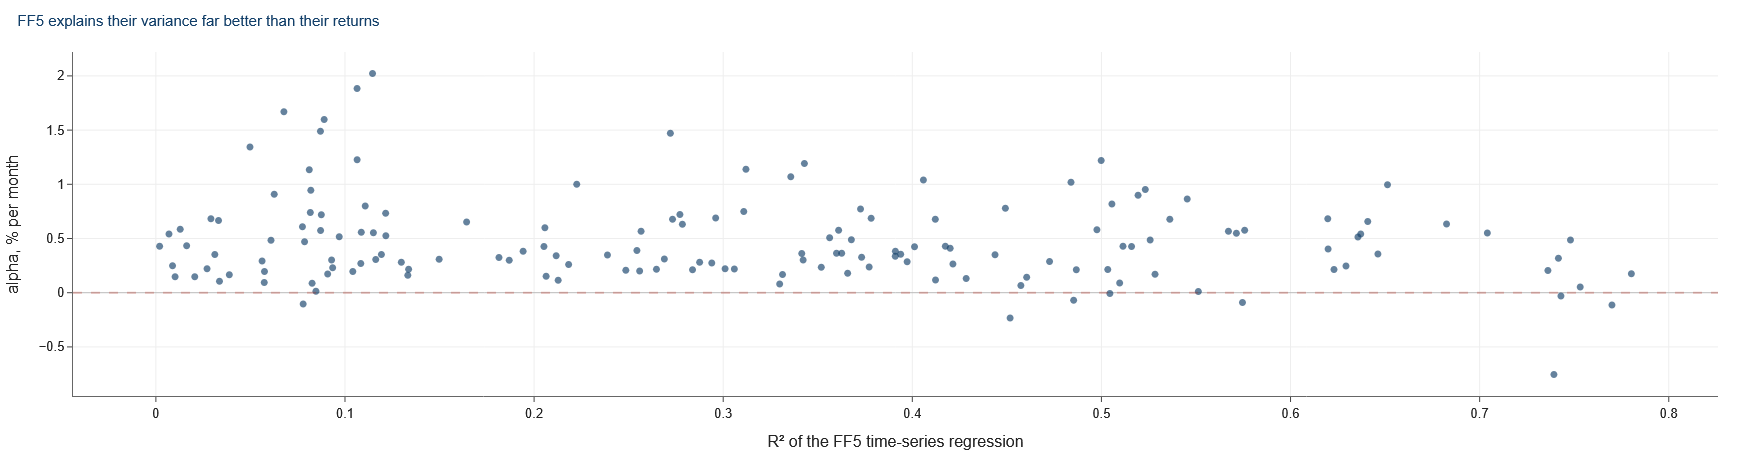

In [14]:
f, _ = load_factors("ff5")
idx = zoo.index.intersection(f.index)
a, _, res, r2 = time_series_alphas(zoo.loc[idx], f.loc[idx])

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=r2, y=a * 100, mode="markers",
    marker=dict(color=NAVY, size=7, opacity=0.65),
    text=r2.index, hovertemplate="%{text}<br>R² %{x:.2f}<br>"
                                 "alpha %{y:.3f}%/mo<extra></extra>",
    name="anomaly"))
fig.add_hline(y=0, line=dict(color=RED, width=2, dash="dash"))
fig.update_xaxes(title="R² of the FF5 time-series regression")
fig.update_yaxes(title="alpha, % per month")
airm_layout(fig, "FF5 explains their variance far better than their returns")

---
## Exercises

### Core

**C1.** Rerun the Part 4 grid on the equal-weighted panels instead of the
value-weighted ones (`load_french(..., panel="Average Equal Weighted Returns -- Monthly")`).
Do the conclusions change? Which portfolios move most, and why would you expect those
ones?

**C2.** The Part 4 grid uses a common sample from 1963. Split it at 1993 and run both
halves. Is any model's advantage stable across the two periods?

**C3.** Add momentum to FF5 to make a six-factor model. Does it help on any of the
three test-asset sets? Relate your answer to how each set was constructed.

**C4.** For the 25 size and book-to-market portfolios, identify the single portfolio
with the largest FF5 alpha. Where does it sit in the size and value grid, and does
that location match what you know about where anomalies concentrate?

### Stretch

**S1.** The GRS test needs $T > N + K$, which fails for large sets of test assets.
Implement a bootstrap alternative that does not, and compare the two on the 25
portfolios where both are available.

**S2.** Part 5 showed the market risk price coming out negative because the test
assets barely spread out on market beta. Construct a set of test assets that *does*
spread on beta — sorting stocks or portfolios on their own past beta is one route —
and check whether $\lambda_{\text{mkt}}$ recovers.

**S3.** GRS assumes normal, homoskedastic, serially uncorrelated residuals. Test each
assumption on the FF5 residuals for the 25 portfolios. Which is violated most badly,
and in which direction would that bias the test?

**S4.** Take the ridge SDF you estimated in Lecture 8b and use it as a single factor
in the machinery here. Does it price the 25 size and book-to-market portfolios better
than FF5? Be careful about the sample split — the SDF was estimated on the first half
of the zoo's history, and using its in-sample period as the test period would be
circular.

**S5.** The Part 6 scatter shows alpha against $R^2$ for 158 anomalies. Is there a
relationship? If anomalies with high $R^2$ have smaller alphas, what would that
suggest about whether the factors are absorbing the anomalies or merely correlating
with them?

---

### Where this sits in the subject

That completes Lecture 8. Across four notebooks you have built the estimators
(**8a**), applied them to the published zoo (**8b**), tested the standard models
against it (**8c**), and pushed complexity to its limit (**8d**).

Lectures 10 and 11 take up the governance question: when the model is a transformer
with tens of thousands of parameters, which of the diagnostics you have used here
would survive an audit — and what do you owe a regulator who asks why a client's
portfolio holds what it holds?